In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import os
import logging


c:\Users\diego\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\diego\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
logging.basicConfig(
    filename='logs/testing.log',
    level=logging.INFO,
    format='%(asctime)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

def log(msg):
    print(msg)
    logging.info(msg)

In [3]:
# --- Configuración Global ---
INITIAL_CASH = 1000000
UP_FACTOR = 1.0002
DOWN_FACTOR = 0.999995
ATR_MULTIPLIER = 0.3

def asegurar_ruta(ruta):
    """Crea la carpeta o subcarpeta si no existe"""
    if not os.path.exists(ruta):
        os.makedirs(ruta)

def log_sim(msg, verbose=False):
    if verbose: log(f"LOG: {msg}")

def calcular_atr_simulado(precios, period=14):
    """Calcula un ATR simplificado basado en el histórico de la simulación."""
    if len(precios) < period:
        return 0.00015 # Valor por defecto si no hay suficiente historia
    
    # Usamos la desviación estándar como proxy de volatilidad para la simulación
    return np.std(precios[-period:]) * 0.5



In [4]:
def simular_estrategia(csv_path, mode='full'):
    base_name_clean = os.path.basename(csv_path).replace('price_records_', '').replace('.csv', '')
    
    # Definir y asegurar carpeta de destino: testing/USDCAD/
    target_dir = os.path.join('testing', base_name_clean)
    asegurar_ruta(target_dir)    
    df = pd.read_csv(csv_path)
    # Extraemos el nombre base para el archivo (ej: USDCAD)
    base_name_clean = os.path.basename(csv_path).replace('price_records_', '').replace('.csv', '')
    
    cash = INITIAL_CASH
    position = 0
    equity_hist = []
    ops_hist = [] 
    actions_hist = []
    
    compras_seguidas = 0
    ventas_fallidas = 0
    esperando_recuperacion = False
    last_entry_price = 0
    trade_returns = [] 
    buy_prices = [] 
    
    prev_high = prev_low = None
    kelly_pct = 0.10 

    for i in range(len(df)):
        current_price = df.loc[i, 'price']
        action_taken = "NO_ACTION"
        
        if mode == 'replica':
            csv_action = df.loc[i, 'action']
            if csv_action in ['BUY', 'RECOVERY', 'OPPORTUNITY']:
                qty = (cash * kelly_pct) / current_price
                position += qty; cash -= qty * current_price; buy_prices.append(current_price)
                action_taken = csv_action
                color = 'red' if csv_action == 'BUY' else ('purple' if csv_action == 'RECOVERY' else 'blue')
                ops_hist.append((i, current_price, color, csv_action))
            elif csv_action in ['SELL', 'PANIC_SELL'] and position > 0:
                avg_buy = np.mean(buy_prices) if buy_prices else current_price
                trade_returns.append(current_price - avg_buy)
                buy_prices = []; cash += position * current_price; position = 0
                action_taken = csv_action
                color = 'green' if csv_action == 'SELL' else 'orange'
                ops_hist.append((i, current_price, color, csv_action))
        
        else:
            if prev_high is None or prev_low is None:
                atr_val = calcular_atr_simulado(df['price'][:i+1].tolist())
                distancia = atr_val * ATR_MULTIPLIER
                prev_high, prev_low = current_price + distancia, current_price - distancia

            if esperando_recuperacion and mode in ['full', 'no_op']:
                if current_price >= last_entry_price * UP_FACTOR or current_price >= prev_high:
                    qty = (cash * kelly_pct) / current_price
                    position += qty; cash -= qty * current_price; buy_prices.append(current_price)
                    action_taken = "RECOVERY"
                    ops_hist.append((i, current_price, 'purple', "RECOVERY"))
                    esperando_recuperacion = False; compras_seguidas = 0; prev_high = prev_low = None

            elif current_price > prev_high:
                if position > 0:
                    avg_buy = np.mean(buy_prices) if buy_prices else current_price
                    trade_returns.append(current_price - avg_buy)
                    buy_prices = []; cash += position * current_price; position = 0
                    action_taken = "SELL"
                    ops_hist.append((i, current_price, 'green', "SELL"))
                    ventas_fallidas = 0; compras_seguidas = 0; prev_high = prev_low = None
                else:
                    ventas_fallidas += 1
                    if ventas_fallidas >= 3 and mode in ['full', 'no_panic']:
                        qty = (cash * kelly_pct) / current_price
                        position += qty; cash -= qty * current_price; buy_prices.append(current_price)
                        action_taken = "OPPORTUNITY"
                        ops_hist.append((i, current_price, 'blue', "OPPORTUNITY"))
                        ventas_fallidas = 0; prev_high = prev_low = None

            elif current_price < prev_low:
                ventas_fallidas = 0; compras_seguidas += 1
                if compras_seguidas < 3:
                    qty = (cash * kelly_pct) / current_price
                    position += qty; cash -= qty * current_price; buy_prices.append(current_price)
                    action_taken = "BUY"; last_entry_price = current_price
                    ops_hist.append((i, current_price, 'red', "BUY"))
                    prev_high = prev_low = None
                elif mode in ['full', 'no_op']:
                    avg_buy = np.mean(buy_prices) if buy_prices else current_price
                    trade_returns.append(current_price - avg_buy)
                    buy_prices = []; cash += position * current_price; position = 0
                    action_taken = "PANIC_SELL"
                    ops_hist.append((i, current_price, 'orange', "PANIC_SELL"))
                    esperando_recuperacion = True; prev_high = prev_low = None

        equity_hist.append(cash + (position * current_price))
        actions_hist.append(action_taken)

    # --- Guardar CSV en la subcarpeta ---
    output_csv = os.path.join(target_dir, f"price_simulation_{mode}_{base_name_clean}.csv")
    df_result = pd.DataFrame({
        'timestamp': df['timestamp'], 'price': df['price'],
        'action': actions_hist, 'equity': equity_hist
    })
    df_result.to_csv(output_csv, index=False)

    # Métricas
    wins = [r for r in trade_returns if r > 0]
    losses = [r for r in trade_returns if r <= 0]
    wr = (len(wins) / len(trade_returns) * 100) if trade_returns else 0
    wl = (np.mean(wins) / abs(np.mean(losses))) if (wins and losses) else 1.0
    
    metrics = {
        'wr': wr, 'wl': wl, 'cash': cash, 'pos': position, 
        'equity': equity_hist[-1], 'pnl': equity_hist[-1] - INITIAL_CASH,
        'trades': len(trade_returns), 'kelly': kelly_pct, 
        'file': os.path.basename(csv_path), 'mode': mode, 'base_name': base_name_clean,
        'target_dir': target_dir # Guardamos la ruta para el plot
    }
    
    return df_result, equity_hist, ops_hist, metrics

In [5]:
def imprimir_resumen(m, estrategia_nombre):
    log(f"\nProcesando: {m['file']}")
    log(f"{estrategia_nombre}: {m['file']}")
    log(f"  Win rate estimado: {m['wr']:.2f}%")
    log(f"  W/L estimado:      {m['wl']:.2f}")
    log(f"  Kelly stake:       {m['kelly']*100:.2f}%")
    log(f"  Caja final:        ${m['cash']:,.2f}")
    log(f"  Posición final:    {int(m['pos'])}")
    log(f"  Equity final:      ${m['equity']:,.2f}")
    log(f"  PnL:               ${m['pnl']:,.2f}")
    log(f"  Trades:            {m['trades']}")

In [6]:
# --- 3. FUNCIONES DE VISUALIZACIÓN ---
def plot_results(df, equity, ops, m):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    ax1.plot(df.index, df['price'], color='black', alpha=0.3, label='Precio Spot')
    
    tipos = {
        'BUY': ('red', 'Compra'), 'SELL': ('green', 'Venta'),
        'PANIC_SELL': ('orange', 'Pánico'), 'RECOVERY': ('purple', 'Recuperación'),
        'OPPORTUNITY': ('blue', 'Oportunidad')
    }
    
    vistos = set()
    for idx, price, color, tipo in ops:
        lbl = tipos[tipo][1] if tipo not in vistos else ""
        ax1.scatter(idx, price, color=color, s=60, edgecolors='black', label=lbl, zorder=5)
        vistos.add(tipo)
    
    ax1.set_title(f"Simulación {m['mode'].upper()} - {m['base_name']}", fontsize=14)
    ax1.legend(loc='upper left', fontsize='small', ncol=3)
    ax1.grid(True, alpha=0.2)

    ax2.plot(df.index, equity, color='#1f77b4', lw=2)
    ax2.set_ylim(min(equity) * 0.999, max(equity) * 1.001)
    ax2.axhline(INITIAL_CASH, color='black', ls='--')
    ax2.set_ylabel("Equity (USD)")
    ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    save_path = os.path.join(m['target_dir'], f"plot_{m['mode']}_{m['base_name']}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=130)
    log(f"✅ Archivos guardados en: {m['target_dir']}")
    plt.show()
    log(f"Gráfico guardado en: {save_path}")

In [7]:
def ejecutar_analisis(archivo_csv):
    path_completo = f"registers/{archivo_csv}"
    configuraciones = [('replica', 'Réplica'), ('no_op', 'Sin Oportunidad'), 
                       ('no_panic', 'Sin Pánico'), ('basic', 'Básica')]
    
    for m_id, m_name in configuraciones:
        df, eq, ops, m = simular_estrategia(path_completo, mode=m_id)
        imprimir_resumen(m, f"Estrategia {m_name}")
        plot_results(df, eq, ops, m)


Procesando: price_records_EURCAD.csv
Estrategia Réplica: price_records_EURCAD.csv
  Win rate estimado: 0.00%
  W/L estimado:      1.00
  Kelly stake:       10.00%
  Caja final:        $1,000,000.00
  Posición final:    0
  Equity final:      $1,000,000.00
  PnL:               $0.00
  Trades:            0
✅ Archivos guardados en: testing\EURCAD


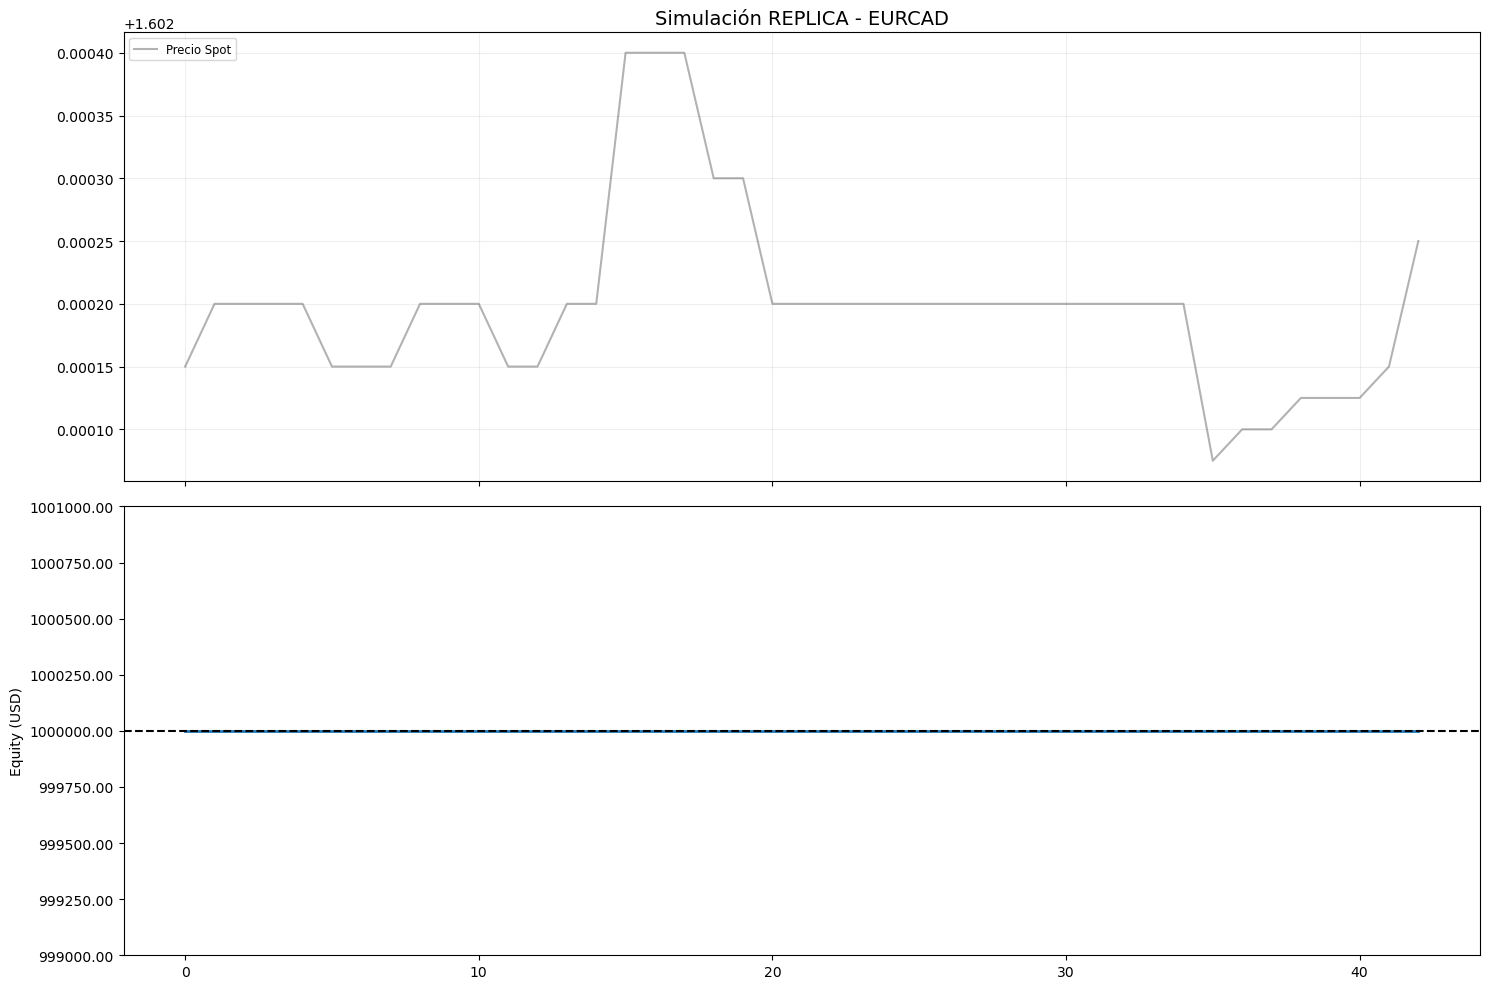

Gráfico guardado en: testing\EURCAD\plot_replica_EURCAD.png

Procesando: price_records_EURCAD.csv
Estrategia Sin Oportunidad: price_records_EURCAD.csv
  Win rate estimado: 100.00%
  W/L estimado:      1.00
  Kelly stake:       10.00%
  Caja final:        $1,000,003.12
  Posición final:    0
  Equity final:      $1,000,003.12
  PnL:               $3.12
  Trades:            1
✅ Archivos guardados en: testing\EURCAD


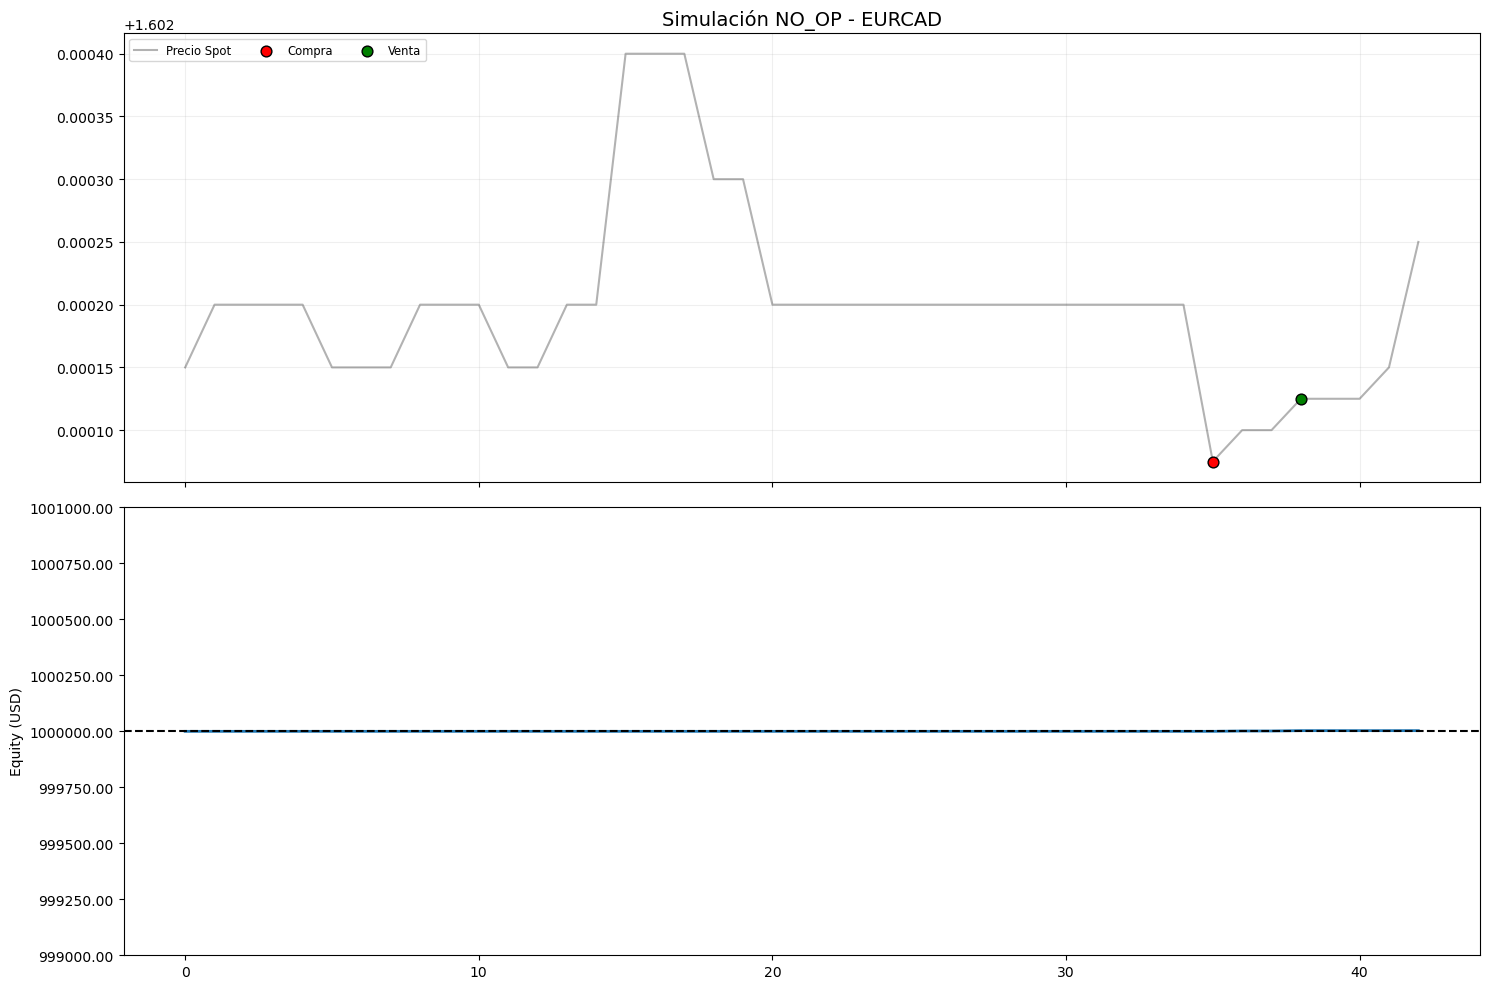

Gráfico guardado en: testing\EURCAD\plot_no_op_EURCAD.png

Procesando: price_records_EURCAD.csv
Estrategia Sin Pánico: price_records_EURCAD.csv
  Win rate estimado: 66.67%
  W/L estimado:      0.38
  Kelly stake:       10.00%
  Caja final:        $999,987.08
  Posición final:    0
  Equity final:      $999,987.08
  PnL:               $-12.92
  Trades:            3
✅ Archivos guardados en: testing\EURCAD


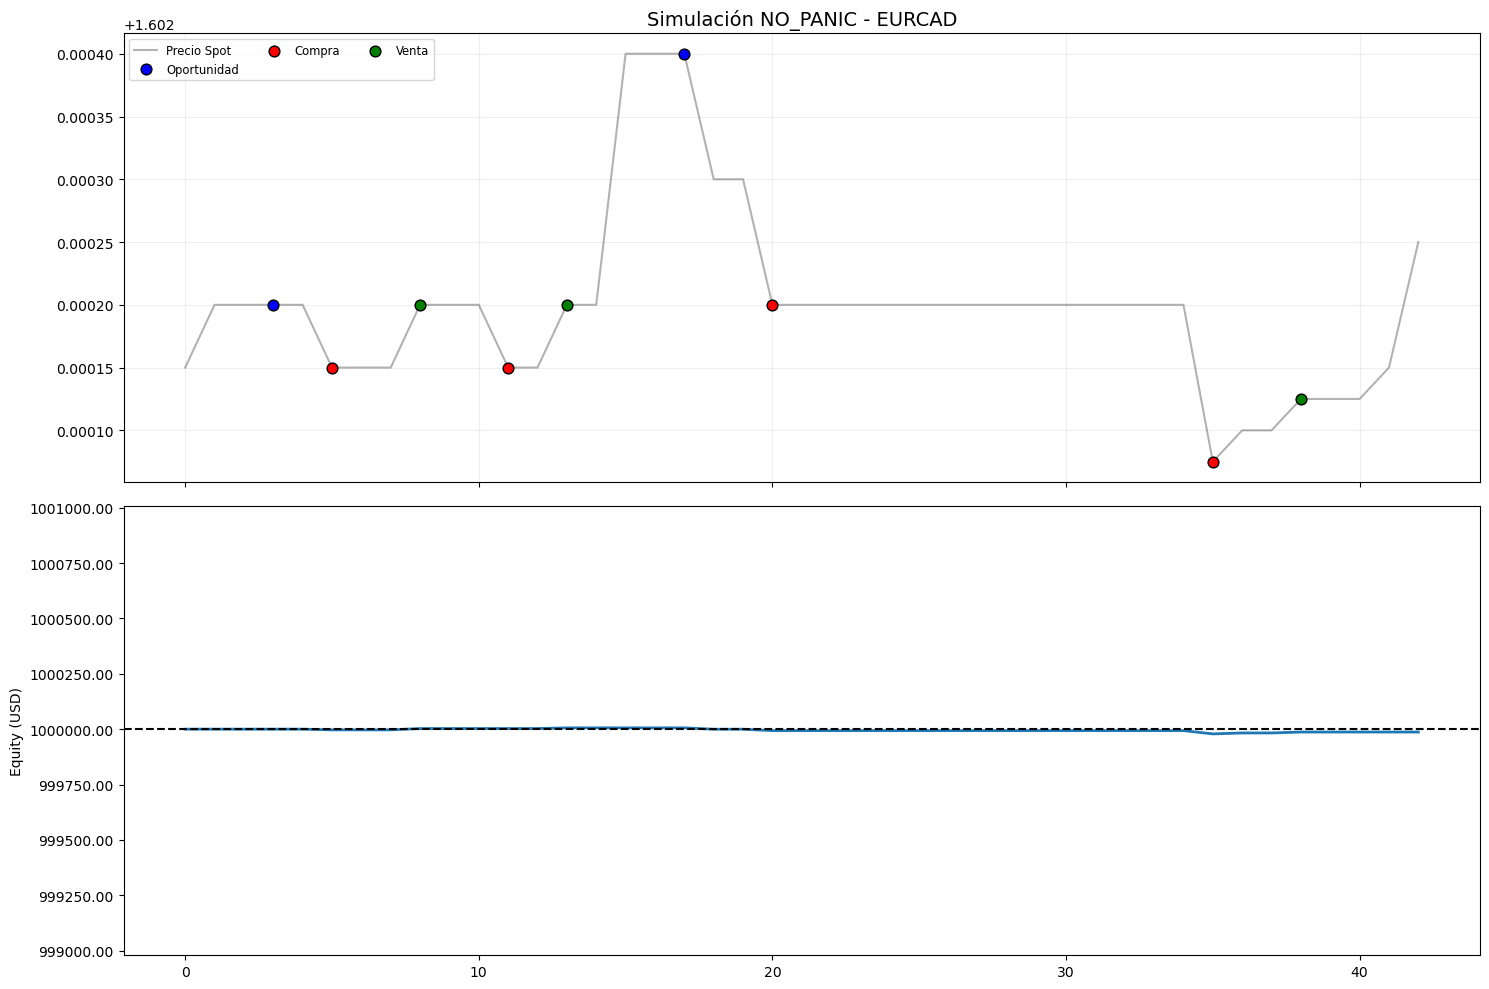

Gráfico guardado en: testing\EURCAD\plot_no_panic_EURCAD.png

Procesando: price_records_EURCAD.csv
Estrategia Básica: price_records_EURCAD.csv
  Win rate estimado: 100.00%
  W/L estimado:      1.00
  Kelly stake:       10.00%
  Caja final:        $1,000,003.12
  Posición final:    0
  Equity final:      $1,000,003.12
  PnL:               $3.12
  Trades:            1
✅ Archivos guardados en: testing\EURCAD


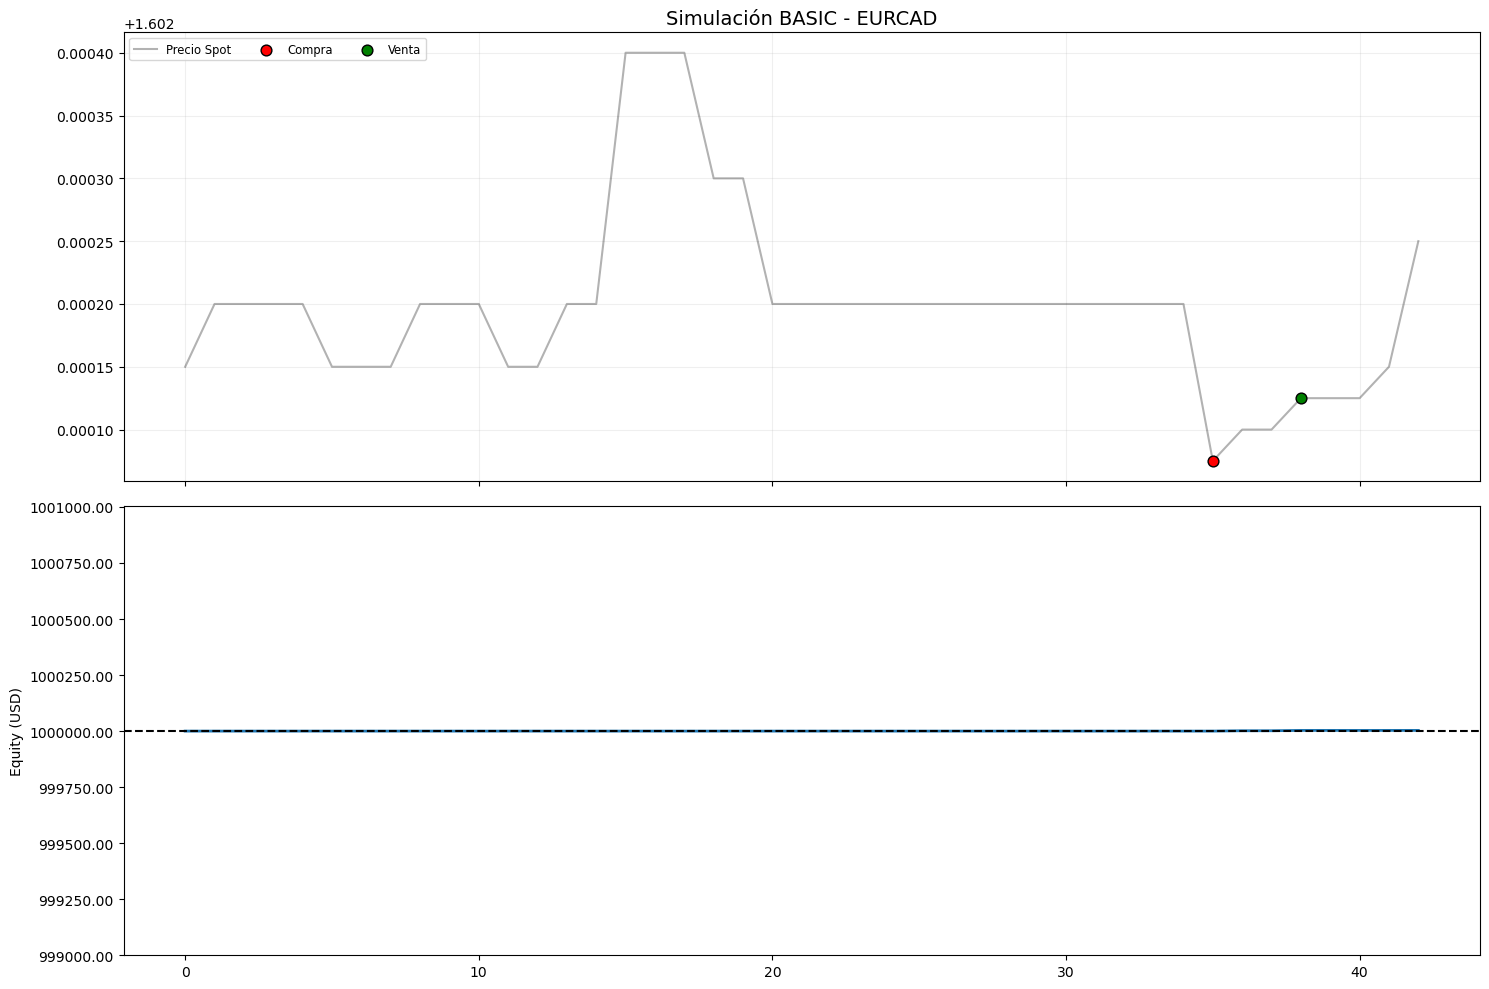

Gráfico guardado en: testing\EURCAD\plot_basic_EURCAD.png


In [8]:
ejecutar_analisis("price_records_EURCAD.csv")